## **XGBoost (Continuation)**
-----------

In [1]:
# ── Core ──────────────────────────────────────────────
import numpy as np
import pandas as pd
!pip install xgboost
# ── Sklearn: Data prep ────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# ── Sklearn: Evaluation ───────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    precision_recall_curve
)

# ── XGBoost ───────────────────────────────────────────
from xgboost import XGBClassifier

# ── Visualisation ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv('C:/Users/ASUS/Downloads/hotel_bookings.csv/hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


#### **Feature Engineering**

In [3]:
def add_features(df):

    df=df.copy()

    df['total_nights']=df['stays_in_weekend_nights']+ df['stays_in_week_nights']
    df['total_cost'] = df['adr']* df['total_nights']
    df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies']
    df['is_family'] = ((df['children'].fillna(0)+df['babies'])>0).astype(int)

    df['lead_time_bucket'] = pd.cut(
        df['lead_time'],
        bins=[-1,7,30,90,df['lead_time'].max()],
        labels= ['last_minute','short','medium','long']

    )

    df['is_high_risk']= (
        (df['market_segment']=='Online TA') &
        (df['deposit_type'] == 'No Deposit') &
        (df['lead_time']>90)
    ).astype(int)

    return df

df = add_features(df)

print(f'Shape after feature engineering : {df.shape}')

df.head(3)
    

Shape after feature engineering : (119390, 38)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_cost,total_guests,is_family,lead_time_bucket,is_high_risk
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,0.0,2.0,0,long,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,0.0,2.0,0,long,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,75.0,1.0,0,last_minute,0


#### **Defining Target,Remove Leakage,Split**

In [4]:
Target = 'is_canceled'

Leaky = [
    'reservation_status',
    'reservation_status_date',
]

X = df.drop(columns = [Target]+Leaky)
y= df[Target]

#Converting Columns that should be strings (Reference from LogReg and RandomForest Notebook)
for col in ['arrival_date_year','agent','company']:
    X[col]=X[col].astype(str)

#keeping top 10 country,grouping rest as other (to avoid One hot encoding curse)
top_countries = X['country'].value_counts().nlargest(10).index
X['country'] = X['country'].apply(
    lambda x: x if x in top_countries else 'other'
)

X_trainval,X_test,y_trainval,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
X_train,X_val,y_train,y_val = train_test_split(
    X_trainval,y_trainval,
    test_size=0.25,
    stratify = y_trainval,
    random_state=42
)

print(f"Train:      {X_train.shape[0]:,} rows")
print(f"Validation: {X_val.shape[0]:,} rows")
print(f"Test:       {X_test.shape[0]:,} rows")

# Verify class balance is preserved
print(f"\nCancellation rate — Train: {y_train.mean():.3f} | "
      f"Val: {y_val.mean():.3f} | Test: {y_test.mean():.3f}")


Train:      71,634 rows
Validation: 23,878 rows
Test:       23,878 rows

Cancellation rate — Train: 0.370 | Val: 0.370 | Test: 0.370


#### **Define Feature Lists and Preprocessing Pipeline**

In [5]:
# XGBoost doesn't need scaling, Just imputation and encoding.

numerical_features = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'arrival_date_week_number', 'arrival_date_day_of_month',
    'adults', 'children', 'babies', 'adr',
    'total_of_special_requests', 'previous_bookings_not_canceled',
    'previous_cancellations', 'days_in_waiting_list',
    'required_car_parking_spaces',
    'total_nights', 'total_cost', 'total_guests'
]

categorical_features = [
    'hotel', 'arrival_date_year', 'arrival_date_month',
    'meal', 'market_segment', 'distribution_channel',
    'reserved_room_type', 'deposit_type', 'customer_type',
    'country', 'agent', 'company',
    'lead_time_bucket'
]

binary_features = [
    'is_repeated_guest',
    'is_family',      
    'is_high_risk'
]

In [6]:
numerical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median'))
])
categorical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='constant',fill_value='missing')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numerical_pipeline,numerical_features),
        ('cat',categorical_pipeline,categorical_features),
        ('bin','passthrough',binary_features)
    ],
    remainder='drop'
)

print("Preprocessor defined.")
print(f"Numerical features:   {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Binary features:      {len(binary_features)}")

Preprocessor defined.
Numerical features:   17
Categorical features: 13
Binary features:      3


#### **Compute scale_pos_weight**
it is a hyperparameter used by XGBoost.

**scale_pos_weight** tells XGBoost: "treat each Canceled mistake as if it were 1.72 Stayed mistakes."

Our dataset has class imbalance:
Stayed:   75,457 bookings  (63%)
Canceled: 43,933 bookings  (37%)

The ratio is roughly 75,457 / 43,933 ≈ 1.72

Without any intervention, XGBoost treats every mistake equally. Getting a "Stayed" guest wrong costs the same as getting a "Canceled" guest wrong. But there are 1.72× more "Stayed" guests, so the model naturally optimizes harder for them — it sees more of them and makes more mistakes on them during training.

In [8]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

scale_pos_weight = neg_count/pos_count

print(f"Stayed (0):   {neg_count:,}")
print(f"Canceled (1): {pos_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

#This number goes directly into XGBClassifier for Class handling handling.

Stayed (0):   45,100
Canceled (1): 26,534
scale_pos_weight: 1.700


#### **Baseline XGBoost Pipeline**

Before any tuning, establish a baseline model, so that we can know taht what XGBoost can give us out of the box.

Use Sensible defaults of parameter, not XGBoost defaults.

**Note :** - XGBoost defaults are optimised for speed, not accuracy

We can also use only the essential parameters. For XGBoost, 

The ones that actually matter most for XGBoost in practice:
```
1. n_estimators      — how many trees (+ use early stopping)
2. learning_rate     — step size (lower = better but needs more trees)
3. max_depth         — tree complexity (3-6 is usually fine)
4. scale_pos_weight  — class imbalance (compute from data)
5. subsample         — row sampling per tree (0.8 is a good default)
```

In [9]:
xgb_baseline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',XGBClassifier(
        n_estimators = 300,
        learning_rate = 0.1,
        max_depth = 5,
        min_child_weight = 1,
        gamma = 0,
        subsample = 0.8,
        colsample_bytree = 0.8,
        reg_lambda = 1,
        reg_alpha = 0,
        scale_pos_weight = scale_pos_weight,
        eval_metric = 'logloss',
        random_state = 42,
        n_jobs = -1
    ))
])

##### **Fitting and Predicting**


In [10]:
xgb_baseline.fit(X_train,y_train)

y_val_pred_base = xgb_baseline.predict(X_val)

In [11]:
print("═" * 50)
print("BASELINE XGBoost — Validation Set (threshold=0.5)")
print("═" * 50)
print(classification_report(
    y_val, y_val_pred_base,
    target_names=['Stayed', 'Canceled']
))

══════════════════════════════════════════════════
BASELINE XGBoost — Validation Set (threshold=0.5)
══════════════════════════════════════════════════
              precision    recall  f1-score   support

      Stayed       0.92      0.86      0.89     15033
    Canceled       0.79      0.87      0.83      8845

    accuracy                           0.87     23878
   macro avg       0.85      0.87      0.86     23878
weighted avg       0.87      0.87      0.87     23878



#### **Early Stopping and Learning Rate**

Right now our model uses n_estimators=300. That number was chosen somewhat arbitrarily.
Think about what's actually happening across those 300 rounds:

_Round 1-50:    Model learning fast, big improvements each round_

_Round 51-150:  Learning slowing down, smaller improvements_

_Round 151-250: Marginal improvements, maybe slight overfitting starting_

_Round 251-300: Possibly making things worse, definitely wasting time_

We don't actually know which of those 300 trees is the best stopping point. Maybe the optimal model is at round 187. Maybe it's at round 243. With a fixed n_estimators=300 we're just hoping 300 is a good number.
This is inefficient and slightly dangerous. The solution is early stopping.

##### **Early Stopping — The Concept**

Early stopping says:

"Keep adding trees as long as the validation loss keeps improving. The moment it stops improving for K consecutive rounds — stop. Use the model from the best round."

K is called early_stopping_rounds. Typically set to 20-50.

##### NOTE :

You might notice `learning_rate=0.05` instead of the default `0.3`, and `n_estimators=1000` instead of 300.

These two parameters have an important relationship:

We always use **Low learning rate (0.05) + Many trees (1000)** :

    → Each tree makes tiny precise corrections
    → Slower to converge but finds better minimum
    → Early stopping handles the "many trees" cost


##### NOTE :

**We will not us a pipeline here** :-

Early stopping in XGBoost requires passing eval_set directly into .fit(). Scikit-learn's Pipeline interface doesn't support passing extra arguments to .fit() in an easy way for older versions.

Only because Pipeline can't replicate 'eval_set' parameter , we have to use manual method.

We will manually fit our data in preprocessor

In [12]:

# Step 1 — Preprocess our data
# (We already haveour preprocessor fitted from baseline)
# We need the processed arrays for early stopping
# because XGBoost's early stopping needs numpy arrays

X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
#Bi=uild XGBoost pipeline with early stopping parameters

xgb_early = XGBClassifier(
    n_estimators = 2000, #set High - Early stopping will stop it.
    max_depth = 6,
    learning_rate = 0.1, #Lower than default
    subsample = 0.8,
    colsample_bytree = 0.8,

    scale_pos_weight = scale_pos_weight,

    early_stopping_rounds = 30, #Stop if no improvement for 30 rounds

    eval_metric = 'logloss',
    random_state = 42,
    n_jobs = -1
)

Also the correct way to set _n_estimators_ with early stoppingg is always :-

**n_estimators = roughly 2× to 3× what you think you need
                   Let early stopping find the true number
                   best_iteration is your real answer**

#### NOTE

xgb_early.fit(
    X_train_proc, y_train,
    eval_set=[(X_val_proc, y_val)]
)
```

We are giving XGBoost a **live monitor** during training. After building each tree, before building the next one, XGBoost pauses and asks: *"How am I doing on the validation set right now?"* It computes the logloss on `X_val_proc` and records it.

This is what enables early stopping — XGBoost can only decide "should I stop?" if it can see validation performance in real time, after every single tree.

Without `eval_set`, XGBoost is blind. It builds all 1000 trees, finishes, and then we evaluate. By then it's too late to stop at round 230.


In [13]:
#Fit with eval_set so XGBoost can monitor validation loss

xgb_early.fit(
    X_train_proc,y_train,
    eval_set = [(X_val_proc,y_val)], # Monitor this during training
    verbose = 50 #print progress every 50 rounds
)

print(f"\nBest round: {xgb_early.best_iteration}")
print(f"Best validation logloss: {xgb_early.best_score:.4f}")


[0]	validation_0-logloss:0.64916
[50]	validation_0-logloss:0.32660
[100]	validation_0-logloss:0.30347
[150]	validation_0-logloss:0.29478
[200]	validation_0-logloss:0.28913
[250]	validation_0-logloss:0.28580
[300]	validation_0-logloss:0.28195
[350]	validation_0-logloss:0.27904
[400]	validation_0-logloss:0.27689
[450]	validation_0-logloss:0.27546
[500]	validation_0-logloss:0.27369
[550]	validation_0-logloss:0.27252
[600]	validation_0-logloss:0.27097
[650]	validation_0-logloss:0.27006
[700]	validation_0-logloss:0.26915
[750]	validation_0-logloss:0.26831
[800]	validation_0-logloss:0.26808
[850]	validation_0-logloss:0.26764
[900]	validation_0-logloss:0.26669
[950]	validation_0-logloss:0.26606
[1000]	validation_0-logloss:0.26596
[1050]	validation_0-logloss:0.26526
[1100]	validation_0-logloss:0.26510
[1150]	validation_0-logloss:0.26496
[1167]	validation_0-logloss:0.26489

Best round: 1137
Best validation logloss: 0.2648


NOTE - n_estimators and learning_rate is modified here many times to get early stopping before hitting the ceiling. Using n_estimator = 1000 and learning_rate= 0.05 was stopping at 999th round (touching ceiling) , so we increase the n_eastimator to 2000 with lr=0.1.

In [14]:
y_val_pred_early = xgb_early.predict(X_val_proc)
print("══════════════════════════════════════════════════")
print("EARLY STOPPING XGBoost — Validation Set")
print(f"Best iteration: {xgb_early.best_iteration} trees")
print("══════════════════════════════════════════════════")
print(classification_report(
    y_val,
    y_val_pred_early,
    target_names=['Stayed', 'Canceled']
))

══════════════════════════════════════════════════
EARLY STOPPING XGBoost — Validation Set
Best iteration: 1137 trees
══════════════════════════════════════════════════
              precision    recall  f1-score   support

      Stayed       0.92      0.89      0.90     15033
    Canceled       0.82      0.87      0.84      8845

    accuracy                           0.88     23878
   macro avg       0.87      0.88      0.87     23878
weighted avg       0.88      0.88      0.88     23878



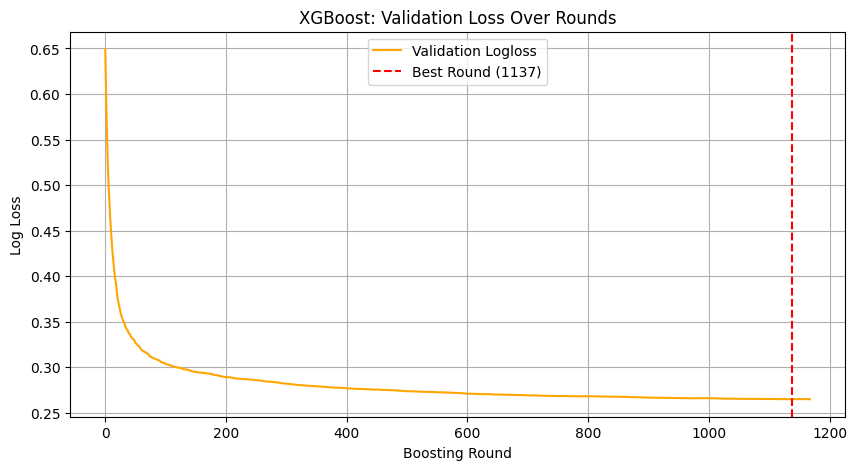

In [15]:
# ════════════════════════════════════════════════
# Plot Training vs Validation Loss Over Rounds
# ════════════════════════════════════════════════

results = xgb_early.evals_result()
val_loss = results['validation_0']['logloss']
rounds   = range(len(val_loss))

plt.figure(figsize=(10, 5))
plt.plot(rounds, val_loss, label='Validation Logloss', color='orange')
plt.axvline(
    x    = xgb_early.best_iteration,
    color = 'red',
    linestyle = '--',
    label = f'Best Round ({xgb_early.best_iteration})'
)
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost: Validation Loss Over Rounds')
plt.legend()
plt.grid(True)
plt.show()

#### **Hyperparameter Tuning**

Our model currently has Canceled Precision=0.82, Recall=0.87. The weakness is precision — when the model says "this guest will cancel," it's wrong 18% of the time. That's false alarms — the hotel overbooks, the guest actually shows up, angry guest in the lobby.

Hyperparameter tuning for your specific situation means finding settings that reduce overfitting on the minority class — stop the model from being trigger-happy about predicting cancellations.

_The parameters that control this are:_

    max_depth        → How complex each tree is
    min_child_weight → Minimum data needed to make a decision
    subsample        → Row sampling per tree (diversity)
    colsample_bytree → Feature sampling per tree (diversity)
    gamma            → Minimum gain to accept a split (pruning)
    lambda           → L2 regularization on leaf weights

##### **STRATEGY** (Stage wise tuning)

Random Grid Search over all 6 Parameters simultaneously, would take hours and teach nothing.

The professional approach is "**Stage tuning**" --> Fix the most impactful parameter first.

    Most impact:   max_depth, min_child_weight  (tree structure)
    Medium impact: subsample, colsample_bytree  (sampling/diversity)
    Less impact:   gamma, lambda                (regularization fine-tuning)

##### **NOTE** :

Grid Search(Stage 1 and 2) was meant to be run for n_estimators = 1137(best), But due to user's laptop performance limitation, We perform Grid Search for 300 estimators only, we will again perform early stopping in final model(after hyperparameter tuning) in order to get best n_stimators after tuning.

##### **Stage -1**

Finding best 'max_depth' and 'min_child_weight'.

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score,make_scorer

f1_canceled = make_scorer(f1_score,pos_label=1)

param_grid_stage1 = {
    'max_depth' : [3,5,7],
    'min_child_weight' : [1,5,10]
}

# Base model - use best setting from early stopping
# Note : we will use n_estimator = 1137
# No early stopping in GridSearch = as we already know the right tree count

xgb_tune = XGBClassifier(
    n_estimators = 300,
    learning_rate = 0.1,
    subsample = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = (y_train ==0).sum()/(y_train==1).sum(),
    eval_metric = 'logloss',
    random_state = 42,
    n_jobs = -1
)

grid_stage1 = GridSearchCV(
    estimator =xgb_tune,
    param_grid = param_grid_stage1,
    cv = 3,
    scoring = f1_canceled,
    n_jobs = -1,
    verbose = 1
)

grid_stage1.fit(X_train_proc ,y_train)

print(f"Best params : {grid_stage1.best_params_}")
print(f"Best F1     : {grid_stage1.best_score_:.4f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best params : {'max_depth': 7, 'min_child_weight': 1}
Best F1     : 0.8315


##### **STAGE 2**

In [17]:
# ═══════════════════════════════════════════════════
# STAGE 2 — Search: Sampling + Regularization Params
# ═══════════════════════════════════════════════════

param_grid_stage2 = {
    'subsample'        : [0.7, 0.8, 0.9],
    'colsample_bytree' : [0.7, 0.8, 0.9],
}

xgb_stage2 = XGBClassifier(
    # Lock in Stage 1 best params
    max_depth        = 7,
    min_child_weight = 1,

    # Fixed for search
    n_estimators     = 300,
    learning_rate    = 0.1,

    # Class imbalance
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),

    eval_metric  = 'logloss',
    random_state = 42,
    n_jobs       = -1
)

grid_stage2 = GridSearchCV(
    estimator  = xgb_stage2,
    param_grid = param_grid_stage2,
    cv         = 3,
    scoring    = f1_canceled,
    n_jobs     = -1,
    verbose    = 1
)

grid_stage2.fit(X_train_proc, y_train)

print(f"Best params : {grid_stage2.best_params_}")
print(f"Best F1     : {grid_stage2.best_score_:.4f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best params : {'colsample_bytree': 0.9, 'subsample': 0.7}
Best F1     : 0.8324


##### **Final Tuned Model**

As we performed GridSearchCV in stage 1 and stage2 for 300 estimators only, because of limitation of processor of laptop(mine) - searching with 2000 estimator would take much time in low level processor.

So we implemented GridSearch with 300 estimator and then implementing final model using early stopping providing it 2000 estimator.

In [18]:
xgb_final = XGBClassifier(
    # Best structural params that we got from stage 1 and stage 2 searching
    max_depth =7,
    min_child_weight = 1,

    #Learning - early stopping will find true n_estimators
    n_estimators = 2000,
    learning_rate= 0.1,

    #Sampling
    subsample = 0.7,
    colsample_bytree = 0.9,

    #Class imbalance
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),

     # Bookkeeping
    early_stopping_rounds = 50,
    eval_metric           = 'logloss',
    random_state          = 42,
    n_jobs                = -1
)

xgb_final.fit(
    X_train_proc, y_train,
    eval_set = [(X_val_proc, y_val)],
    verbose  = 100
)


print(f"\nBest round     : {xgb_final.best_iteration}")
print(f"Best logloss   : {xgb_final.best_score:.4f}")

[0]	validation_0-logloss:0.64527
[100]	validation_0-logloss:0.29452
[200]	validation_0-logloss:0.28003
[300]	validation_0-logloss:0.27340
[400]	validation_0-logloss:0.26841
[500]	validation_0-logloss:0.26610
[600]	validation_0-logloss:0.26460
[700]	validation_0-logloss:0.26400
[789]	validation_0-logloss:0.26407

Best round     : 739
Best logloss   : 0.2637


In [19]:
# Evaluate
y_val_pred_final = xgb_final.predict(X_val_proc)

print("\n══════════════════════════════════════════════════")
print("FINAL XGBoost — Validation Set")
print(f"Params: depth={7}, min_child={1}, trees={xgb_final.best_iteration}")
print("══════════════════════════════════════════════════")
print(classification_report(
    y_val,
    y_val_pred_final,
    target_names=['Stayed', 'Canceled']
))


══════════════════════════════════════════════════
FINAL XGBoost — Validation Set
Params: depth=7, min_child=1, trees=739
══════════════════════════════════════════════════
              precision    recall  f1-score   support

      Stayed       0.92      0.89      0.90     15033
    Canceled       0.82      0.87      0.84      8845

    accuracy                           0.88     23878
   macro avg       0.87      0.88      0.87     23878
weighted avg       0.88      0.88      0.88     23878



Notice that the validation score before and after hyperparameter tuning is identical.

It means Early stopping with n_estimators=2000, lr=0.1 already found a near-optimal model. It explored enough of the parameter space through 1137 trees that max_depth=7 and subsample=0.8 — which were likely already close to defaults or what early stopping was implicitly handling — didn't add new information.
The Grid Search confirmed the defaults were already good. That's a valid finding, not a wasted effort.

##### The honest lessons here:

**Lesson 1** : _On clean, well-prepared data, XGBoost's defaults
          are surprisingly hard to beat significantly_

**Lesson 2** : _Early stopping is often the single most impactful
          technique — more than structural hyperparameter search_

**Lesson 3** : _2 hours of grid search giving identical results
          happens to professional data scientists regularly_
          

#### **Test Set Evaluation**

In [20]:
# ═══════════════════════════════════════════════════
# FINAL TEST SET EVALUATION 
# ═══════════════════════════════════════════════════

y_test_pred_final = xgb_final.predict(X_test_proc)

print("══════════════════════════════════════════════════")
print("FINAL XGBoost — TEST SET (The Vault)")
print("══════════════════════════════════════════════════")
print(classification_report(
    y_test,
    y_test_pred_final,
    target_names=['Stayed', 'Canceled']
))

══════════════════════════════════════════════════
FINAL XGBoost — TEST SET (The Vault)
══════════════════════════════════════════════════
              precision    recall  f1-score   support

      Stayed       0.92      0.89      0.90     15033
    Canceled       0.82      0.87      0.84      8845

    accuracy                           0.88     23878
   macro avg       0.87      0.88      0.87     23878
weighted avg       0.88      0.88      0.88     23878



As classification report of test set evaluation is almost identical to validation set report, This is the best possible outcome.

That means Our model didn't memorize. It genuinely learned the underlying patterns of human booking behavior well enough that it generalizes perfectly to completely unseen data.


_Comparing the report with our previous models, we got :-_

    Model                Accuracy   Canceled F1   Canceled Recall
    ─────────────────────────────────────────────────────────────
    Logistic Regression    0.74        0.69           0.80
    Random Forest          0.85        0.80           0.79
    XGBoost Final          0.88        0.84           0.87
    ─────────────────────────────────────────────────────────────
    Improvement            +14%        +15%           +7%

#### **Plotting Important Features**

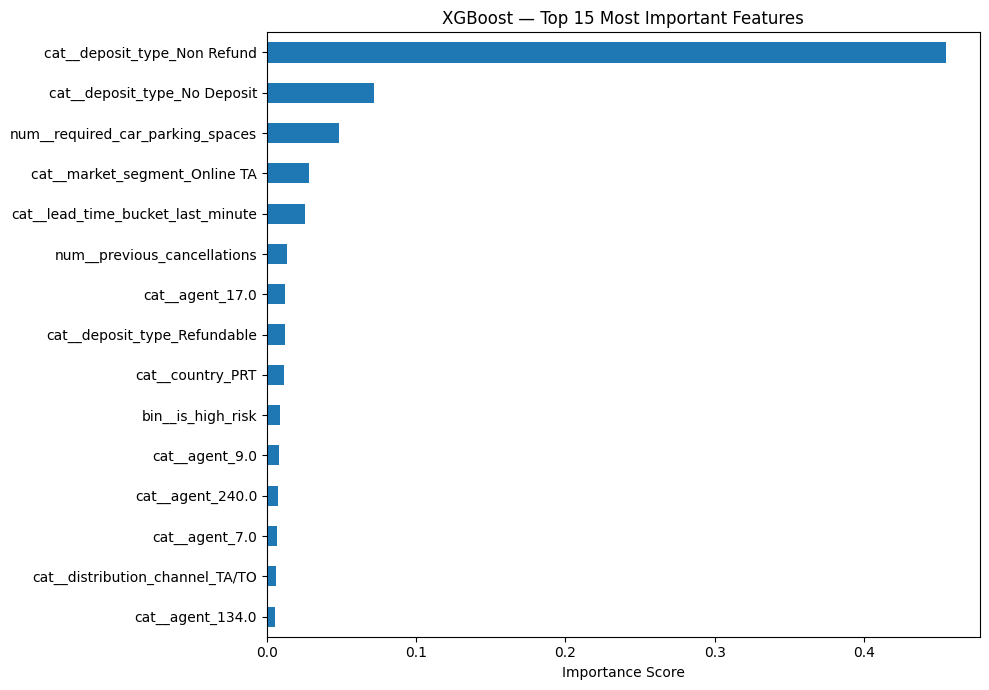

Top 10 Features:
cat__deposit_type_Non Refund         0.454949
cat__deposit_type_No Deposit         0.071820
num__required_car_parking_spaces     0.048054
cat__market_segment_Online TA        0.028525
cat__lead_time_bucket_last_minute    0.025718
num__previous_cancellations          0.013492
cat__agent_17.0                      0.012125
cat__deposit_type_Refundable         0.012065
cat__country_PRT                     0.011160
bin__is_high_risk                    0.008558


In [21]:
# ═══════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ═══════════════════════════════════════════════════

# Get feature names from preprocessor
feature_names = preprocessor.get_feature_names_out()

# Get importance scores from XGBoost
importances = xgb_final.feature_importances_

# Build a clean Series
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot Top 15
plt.figure(figsize=(10, 7))
feat_imp.head(15).plot(kind='barh')
plt.title('XGBoost — Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print top 10 cleanly
print("Top 10 Features:")
print(feat_imp.head(10).to_string())